In [1]:
!unzip /content/drive/MyDrive/Data.zip

Archive:  /content/drive/MyDrive/Data.zip
   creating: Data/
   creating: Data/validation/
   creating: Data/validation/army_worm/
  inflating: Data/validation/army_worm/army_worm (17).jpg  
  inflating: Data/validation/army_worm/army_worm (7).jpg  
  inflating: Data/validation/army_worm/army_worm (5).jpg  
  inflating: Data/validation/army_worm/army_worm (15).jpg  
  inflating: Data/validation/army_worm/army_worm (10).jpg  
  inflating: Data/validation/army_worm/army_worm (18).jpg  
  inflating: Data/validation/army_worm/army_worm (2).jpg  
  inflating: Data/validation/army_worm/army_worm (19).jpg  
  inflating: Data/validation/army_worm/army_worm (13).jpg  
  inflating: Data/validation/army_worm/army_worm (3).jpg  
  inflating: Data/validation/army_worm/army_worm (6).jpg  
  inflating: Data/validation/army_worm/army_worm (12).jpg  
  inflating: Data/validation/army_worm/army_worm (1).jpg  
  inflating: Data/validation/army_worm/army_worm (14).jpg  
  inflating: Data/validation/army_w

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
train_dir = '/content/Data/train'
validation_dir = '/content/Data/validation'

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data (no augmentation, only rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Generate augmented data batches
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,  # Smaller batches due to limited data
    class_mode='binary'  # Use 'categorical' for multi-class
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [5]:
%%time
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load ResNet50 without the top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

model = Model(inputs=base_model.input, outputs=output)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50
)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 129s 8s/step - accuracy: 0.4538 - loss: 5.1449 - val_accuracy: 0.8250 - val_loss: 0.6539
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 68s 6s/step - accuracy: 0.6209 - loss: 3.8109 - val_accuracy: 0.5000 - val_loss: 3.9383
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.4519 - loss: 3.4331 - val_accuracy: 0.5000 - val_loss: 0.8068
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.4886 - loss: 0.8734 - val_accuracy: 0.5750 - val_loss: 0.6469
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 5s/step - accuracy: 0.4687 - loss: 0.6891 - val_accuracy: 0.6250 - val_loss: 0.6807
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.4972 - loss: 0.7116 - val_accuracy: 0.7750 - val_loss: 0.6772
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 58s 5s/step - accuracy: 0.6430 - loss: 0.6872 - val_accuracy: 0.7000 - val_loss: 0.6705
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.5028 - loss: 0.6899 - val_accuracy: 0.5750 - val_loss

In [7]:
%%time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
model2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Train the custom CNN
history_custom = model2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stopping]
)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.4609 - loss: 1.4274 - val_accuracy: 0.5000 - val_loss: 0.6526
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5547 - loss: 0.6785 - val_accuracy: 0.5000 - val_loss: 0.7028
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.6786 - loss: 0.5506 - val_accuracy: 0.7000 - val_loss: 0.5694
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.7837 - loss: 0.4855 - val_accuracy: 0.8000 - val_loss: 0.4267
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.8245 - loss: 0.4081 - val_accuracy: 0.7000 - val_loss: 0.5484
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8126 - loss: 0.3960 - val_accuracy: 0.6750 - val_loss: 0.5079
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7903 - loss: 0.4486 - val_accuracy: 0.7750 - val_loss: 0.4334
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.8662 - loss: 0.3394 - val_accuracy: 0.7750 - val_loss:

In [8]:
%%time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
model3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Train the custom CNN
history_custom = model3.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stopping]
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 95s 8s/step - accuracy: 0.5319 - loss: 1.6648 - val_accuracy: 0.7750 - val_loss: 0.6095
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.6044 - loss: 0.6237 - val_accuracy: 0.6750 - val_loss: 0.5292
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 85s 7s/step - accuracy: 0.8514 - loss: 0.3627 - val_accuracy: 0.8250 - val_loss: 0.3372
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 7s/step - accuracy: 0.7155 - loss: 0.5176 - val_accuracy: 0.7000 - val_loss: 0.6642
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.6356 - loss: 0.6783 - val_accuracy: 0.7500 - val_loss: 0.6534
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 7s/step - accuracy: 0.6074 - loss: 0.6768 - val_accuracy: 0.8250 - val_loss: 0.5631
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 139s 7s/step - accuracy: 0.5648 - loss: 0.7048 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 91s 8s/step - accuracy: 0.4996 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss

In [10]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f"Validation Accuracy for Resnet50 Model: {val_acc*100:.2f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6203 - loss: 0.6733
Validation Accuracy for Resnet50 Model: 60.00%


In [11]:
val_loss, val_acc = model2.evaluate(validation_generator)
print(f"Validation Accuracy for Custom model: {val_acc*100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7984 - loss: 0.4309
Validation Accuracy for Custom model: 80.00%


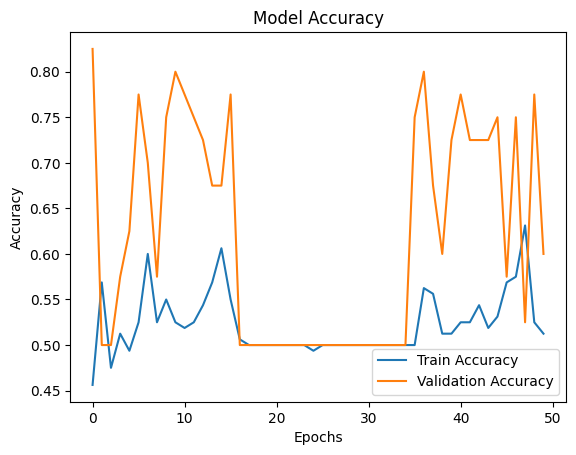

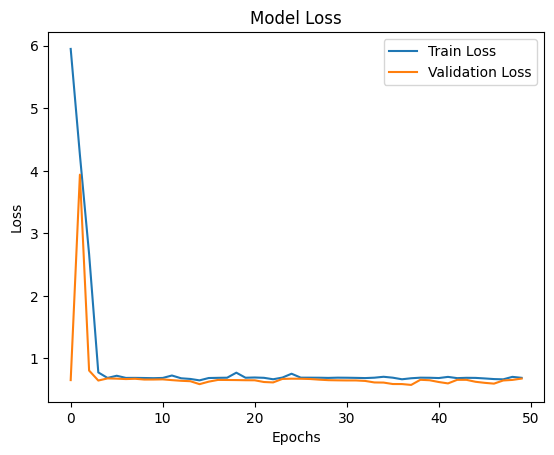

<Figure size 640x480 with 0 Axes>

In [12]:

# For ResNet Model
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.savefig("ResNet50_model_accuarcy.png")

plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
plt.savefig("ResNet50_model_loss.png")




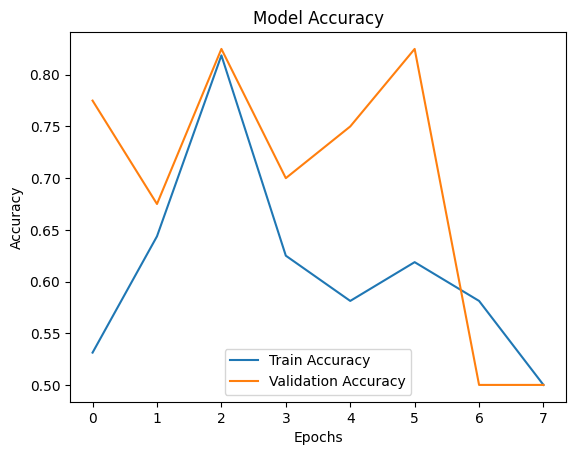

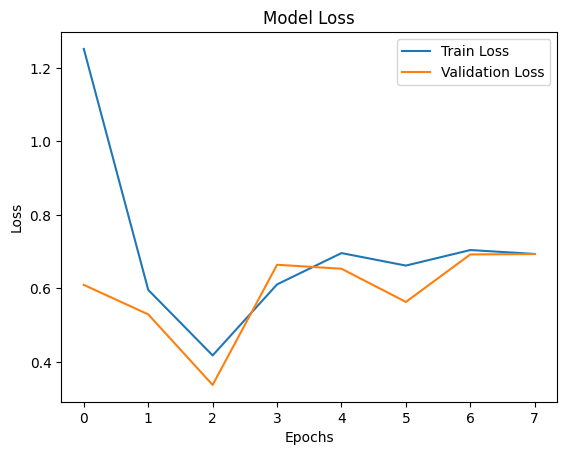

<Figure size 640x480 with 0 Axes>

In [13]:
# For Custom Model
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history_custom.history['accuracy'], label='Train Accuracy')
plt.plot(history_custom.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()
plt.savefig("Custom_model_accuarcy.png")

# Plot loss
plt.plot(history_custom.history['loss'], label='Train Loss')
plt.plot(history_custom.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
plt.savefig("Custom_model_loss.png")


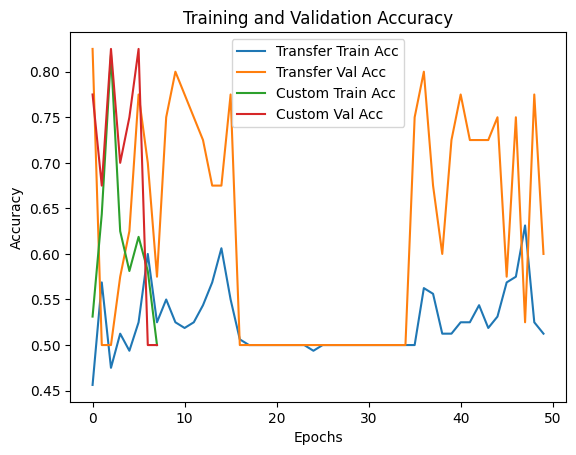

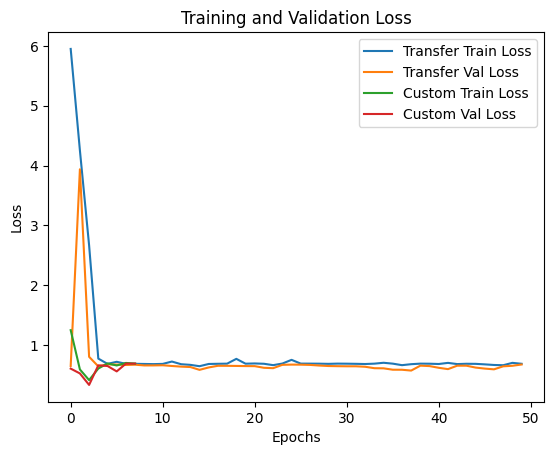

In [14]:
plt.plot(history.history['accuracy'], label='Transfer Train Acc')
plt.plot(history.history['val_accuracy'], label='Transfer Val Acc')
plt.plot(history_custom.history['accuracy'], label='Custom Train Acc')
plt.plot(history_custom.history['val_accuracy'], label='Custom Val Acc')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Transfer Train Loss')
plt.plot(history.history['val_loss'], label='Transfer Val Loss')
plt.plot(history_custom.history['loss'], label='Custom Train Loss')
plt.plot(history_custom.history['val_loss'], label='Custom Val Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [ ]:
model.save('resnet50_model.h5')


In [ ]:
model2.save('custom_model.h5')
